In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
print("Notebook is ready!")

Notebook is ready!


In [2]:
df= pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.shape

(1000, 8)

In [4]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [6]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [8]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

- Dataset contains student exam scores and background factors
- No missing values present
- Scores range from 0 to 100
- Data includes both categorical and numerical features

In [10]:
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.lower()

df.columns

Index(['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='str')

In [11]:
df.head()

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Data Cleaning:
- Renamed columns to lowercase
- Removed spaces and replaced with underscores
- Dataset contains no missing values and no duplicates

In [12]:
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df.head()

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


In [13]:
df['average_score'] = df['total_score'] / 3
df.head()

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [14]:
def performance(avg):
    if avg >= 75:
        return "Good"
    elif avg >= 50:
        return "Average"
    else:
        return "Poor"

df['performance'] = df['average_score'].apply(performance)

df.head()

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score,performance
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667,Average
1,female,group C,some college,standard,completed,69,90,88,247,82.333333,Good
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667,Good
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333,Poor
4,male,group C,some college,standard,none,76,78,75,229,76.333333,Good


Feature Engineering:
- Created total_score by summing all subjects
- Created average_score
- Categorized students into performance levels

In [15]:
df[['math_score', 'reading_score', 'writing_score']].mean().to_frame(name="Average Score")

,Average Score
math_score,66.089
reading_score,69.169
writing_score,68.054


Insights:
- Reading score has the highest average
- Math score is slightly lower compared to other subjects

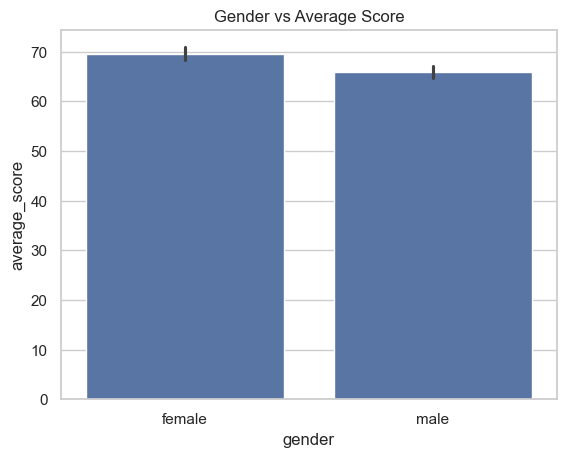

In [16]:
sns.barplot(x='gender', y='average_score', data=df)
plt.title("Gender vs Average Score")
plt.show()

Insight:
- Female students perform better in average score compared to male students

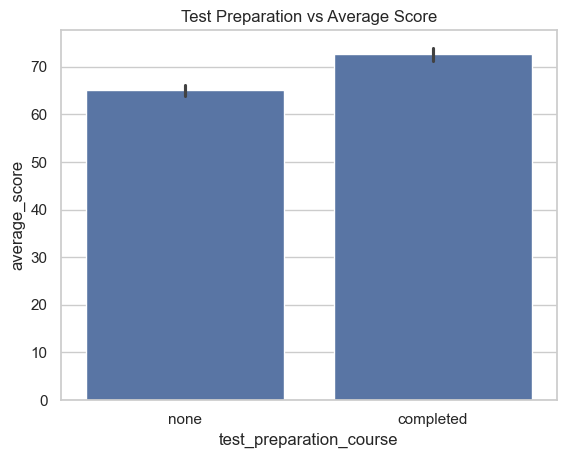

In [17]:
sns.barplot(x='test_preparation_course', y='average_score', data=df)
plt.title("Test Preparation vs Average Score")
plt.show()

Insight:
- Students who compeleted test preparation scored significantly higher

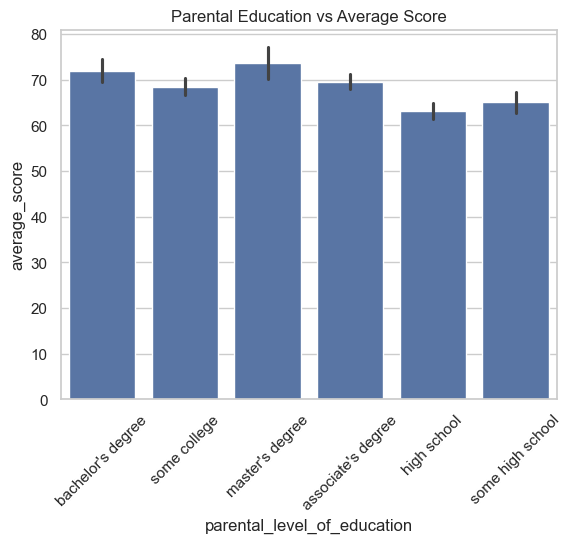

In [18]:
sns.barplot(x='parental_level_of_education', y='average_score', data=df)
plt.xticks(rotation=45)
plt.title("Parental Education vs Average Score")
plt.show()

Insigth:
- Students with highly educated parents tend to perform slightly better

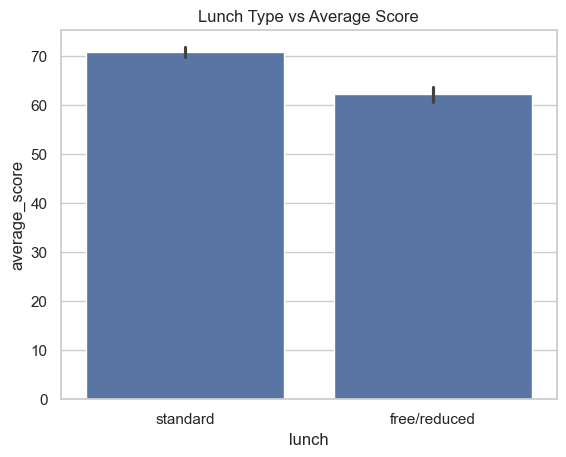

In [19]:
sns.barplot(x='lunch', y='average_score', data=df)
plt.title("Lunch Type vs Average Score")
plt.show()

Insight:
- Students with standard lunch perform better than free/reduced lunch students

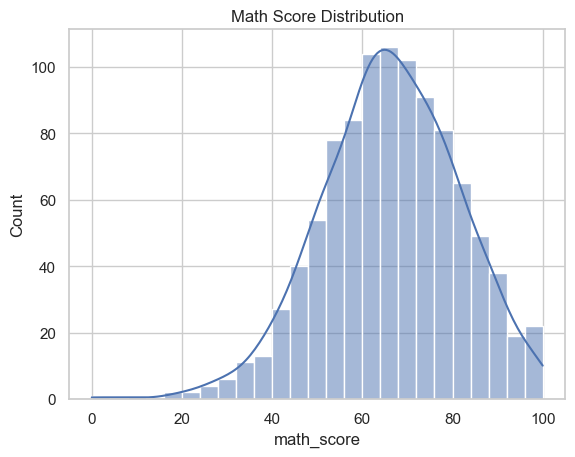

In [20]:
sns.histplot(df['math_score'], kde=True)
plt.title("Math Score Distribution")
plt.show()

Insight:
- Most students score between 60-80 in math

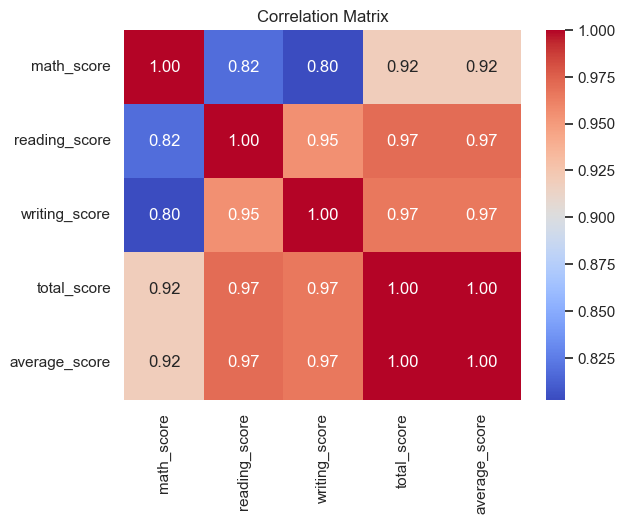

In [22]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

Insight:
- Reading and writing scores are highly correlated
- Math score has moderate correlation with other subjects